# Zomato Data Analysis

1) What type of restaurant do the majority of customers order from?
2) How many votes has each type of restaurant received from customers?
3) What are the ratings that the majority of restaurants have received?
4) How many restaurants accept online orders?
5) Zomato has observed that most couples order most of their food online. What is their average spending on each order?
6) Which mode (online or offline) has received the maximum rating?
7) Which type of restaurant received more offline orders, so that Zomato can give customers with some good offers?
8) Which location has the highest number of restaurants listed on Zomato?
9) Which cuisines are most popular based on total votes received?

## Step - 1 Importing Libraries

In [14]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## Step - 2 Creating the Data Frame

In [15]:
df = pd.read_csv("zomato.csv")
df

,name,order_type,book_table,rate,votes,approx_cost(for two people),listed_in(type),location,cuisines
0,Jalsa,Online,Yes,4.1,775,800,Buffet,Indiranagar,Italian
1,Spice Elephant,Online,No,4.1,787,800,Buffet,Koramangala,North Indian
2,San Churro Cafe,Online,No,3.8,918,800,Buffet,Andheri,Italian
3,Addhuri Udupi Bhojana,Offline,No,3.7,88,300,Buffet,Bandra,Fast Food
4,Grand Village,Offline,No,3.8,166,600,Buffet,Bandra,Fast Food
...,...,...,...,...,...,...,...,...,...
143,Melting Melodies,Offline,No,3.3,0,100,Dining,Indiranagar,Chinese
144,New Indraprasta,Offline,No,3.3,0,150,Dining,Andheri,South Indian
145,Anna Kuteera,Online,No,4.0,771,450,Dining,Sector 18,Chinese
146,Darbar,Offline,No,3.0,98,800,Dining,Park Street,Street Food


#### Convert the data type of column - rate

In [16]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

df['rate'] = df['rate'].apply(handleRate)
df.head()

df['rate'] = df['rate'].astype(float)
df['rate'].dtypes  
df['rate'].head()


0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   order_type                   148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
 7   location                     148 non-null    object 
 8   cuisines                     148 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 10.5+ KB


### 1) What type of restaurant do the majority of customers order from?

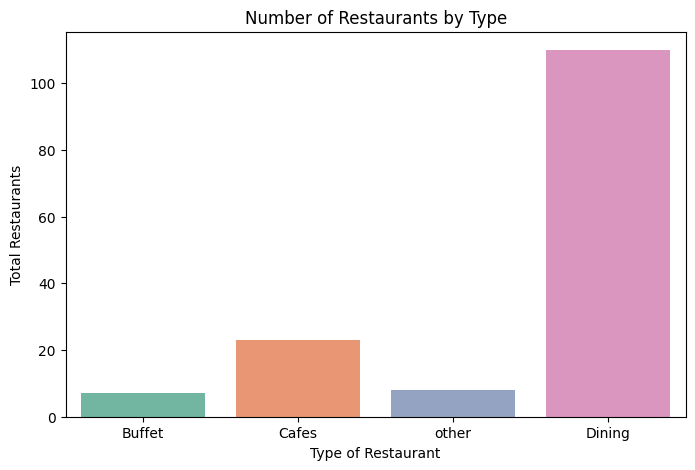

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='listed_in(type)', hue='listed_in(type)', data=df, palette='Set2')
plt.title('Number of Restaurants by Type')
plt.xlabel('Type of Restaurant')
plt.ylabel('Total Restaurants')
plt.show()


1) Insights - Majority of the restaurant falls in dining category

### 2) How many votes has each type of restaurant received from customers?

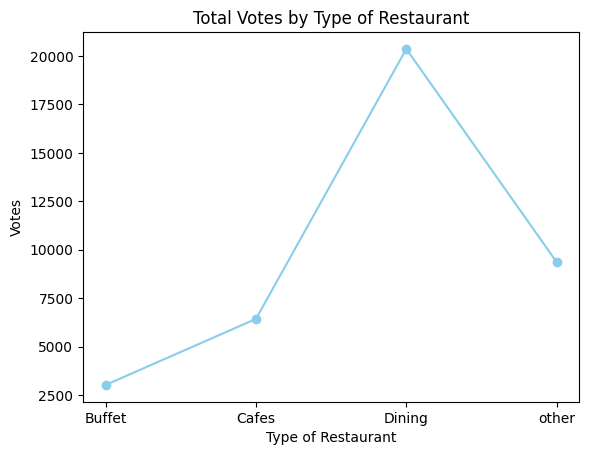

In [19]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c="skyblue", marker="o")
plt.title("Total Votes by Type of Restaurant")
plt.xlabel('Type of Restaurant')
plt.ylabel("Votes")
plt.show()

2) Insights - Dining restaurants has received maximum votes

### 3) What are the ratings that the majority of restaurants have received?

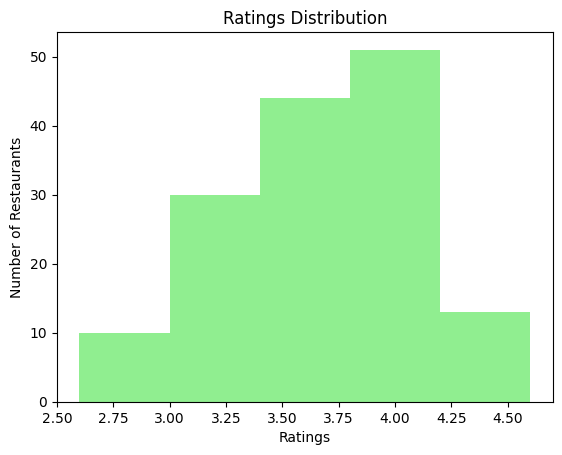

In [20]:
plt.hist(df['rate'], bins = 5, color='lightgreen')
plt.title("Ratings Distribution")
plt.xlabel("Ratings")
plt.ylabel("Number of Restaurants")
plt.show()

3) Insights - The Majority restaurants received ratings from 3.5 to 4

### 4) How many restaurants accept online orders?

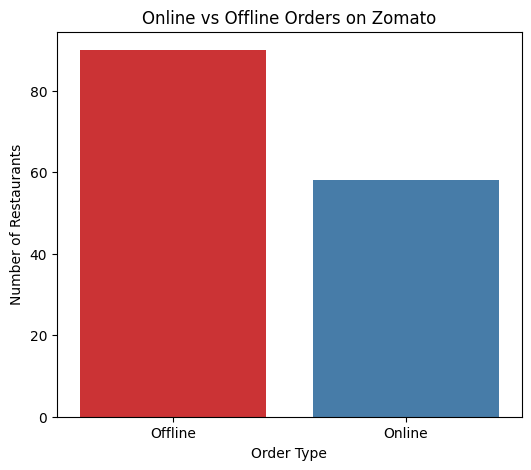

Online Orders: 39.19%
Offline Orders: 60.81%


In [21]:
s = df['order_type'].value_counts()

plt.figure(figsize=(6,5))
sns.barplot(x=s.index, y=s.values, palette='Set1', hue=s.index)
plt.title('Online vs Offline Orders on Zomato')
plt.xlabel('Order Type')
plt.ylabel('Number of Restaurants')
plt.show()

total_orders = s.sum()
percent_online = (s['Online'] / total_orders) * 100
percent_offline = (s['Offline'] / total_orders) * 100

print(f"Online Orders: {percent_online:.2f}%")
print(f"Offline Orders: {percent_offline:.2f}%")

4) Insights - Around 39% of restaurants accept online orders, while 61% still depend on offline methods. This shows that although online ordering is popular, a significant portion of restaurants continues to operate offline, possibly due to traditional customer preferences or limited digital reach.

### 5) Zomato has observed that most couples order most of their food online. What is their average spending on each order?

C:\Users\Akhilesh\AppData\Local\Temp\ipykernel_5292\1828365196.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='order_type', y='approx_cost(for two people)', data=df, estimator=np.mean, palette='cool')


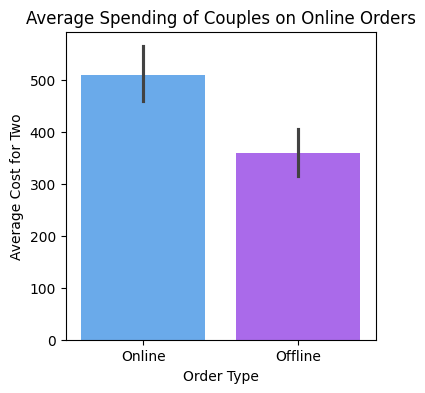

In [22]:
plt.figure(figsize=(4,4))
sns.barplot(x='order_type', y='approx_cost(for two people)', data=df, estimator=np.mean, palette='cool')
plt.title('Average Spending of Couples on Online Orders')
plt.xlabel('Order Type')
plt.ylabel('Average Cost for Two')
plt.show()

5) Insights - Couples mostly prefer online orders and spend about ₹500, which is higher than offline spending.

### 6) Which mode (online or offline) has received the maximum rating?

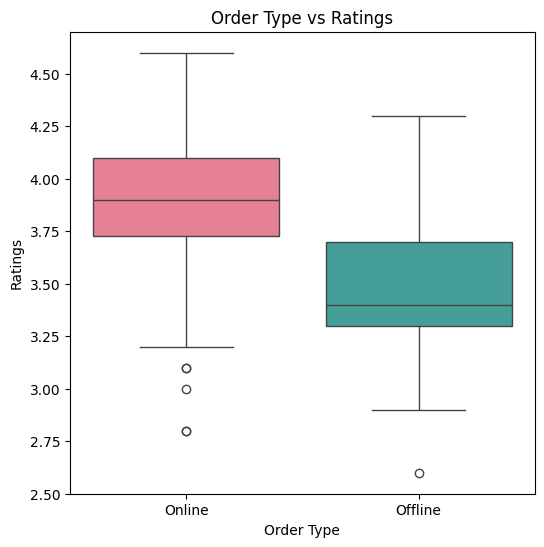

In [23]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'order_type', y = 'rate', data = df, 
           hue='order_type', palette=sns.color_palette("husl", n_colors=2))
plt.title("Order Type vs Ratings")
plt.xlabel("Order Type")
plt.ylabel("Ratings")
plt.show()

6) Insights - Offline order receive lower rating as comapred to online order

### 7) Which type of restaurant received more offline orders, so that Zomato can give customers with some good offers?

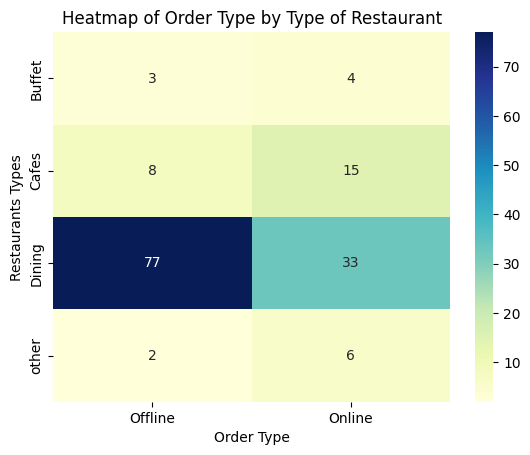

In [24]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='order_type', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title("Heatmap of Order Type by Type of Restaurant")
plt.xlabel("Order Type")
plt.ylabel("Restaurants Types")
plt.show()

7) Insights - Dining restaurants primarily accept offline orders, whereas cafes primarily receive online orders. This suggests that clients prefer orders in person at restaurants, but prefer online ordering at cafes.

### 8) Which location has the highest number of restaurants listed on Zomato?

C:\Users\Akhilesh\AppData\Local\Temp\ipykernel_5292\1325502013.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_count.index, y=location_count.values, palette='Set2')


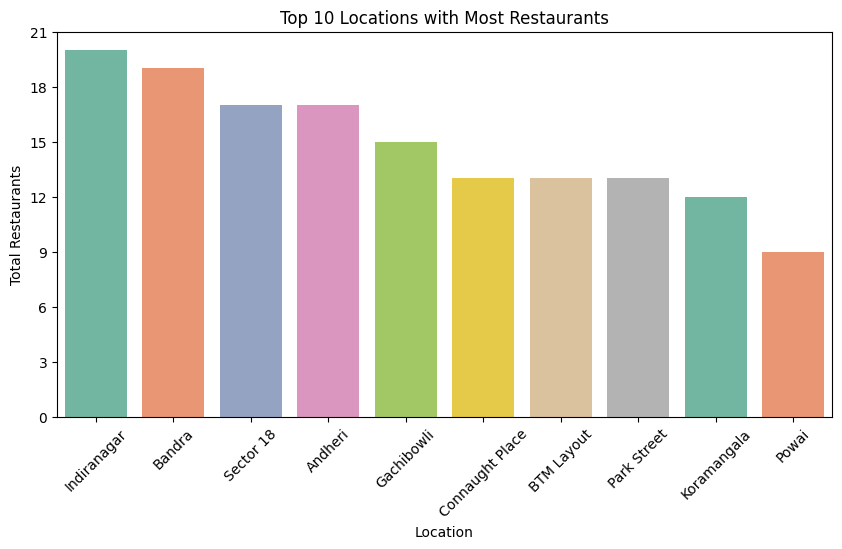

In [25]:
from matplotlib.ticker import MaxNLocator
location_count = df['location'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=location_count.index, y=location_count.values, palette='Set2')
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('Top 10 Locations with Most Restaurants')
plt.xlabel('Location')
plt.ylabel('Total Restaurants')
plt.xticks(rotation=45)
plt.show()


8) Insights - Indiranagar, Bandra and Andheri have the highest number of restaurants.
These areas are popular food hubs with a large mix of cafes, street food joints, and dine-in restaurants that attract both locals and tourists.

### 9) Which cuisines are most popular based on total votes received?

C:\Users\Akhilesh\AppData\Local\Temp\ipykernel_5292\849223638.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_votes.values, y=cuisine_votes.index, palette='viridis')


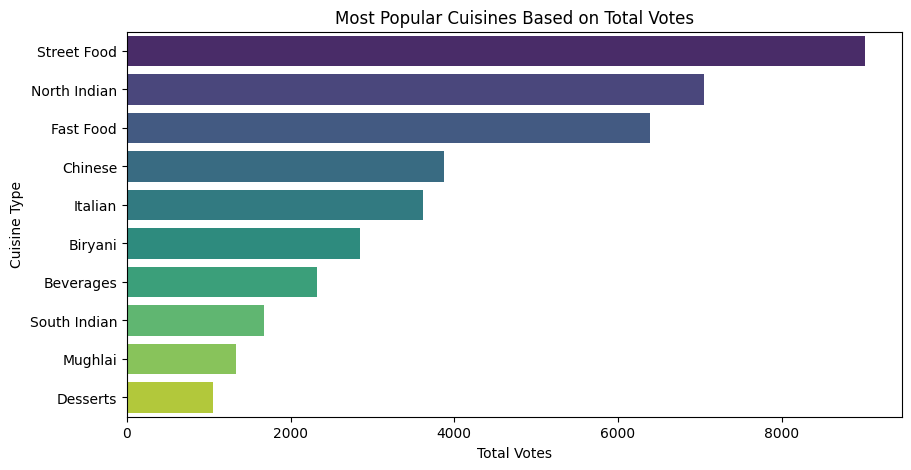

In [26]:
plt.figure(figsize=(10,5))
cuisine_votes = df.groupby('cuisines')['votes'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=cuisine_votes.values, y=cuisine_votes.index, palette='viridis')
plt.title('Most Popular Cuisines Based on Total Votes')
plt.xlabel('Total Votes')
plt.ylabel('Cuisine Type')
plt.show()


9) Insights - Street Food and North Indian cuisines got the highest number of votes, showing they are the most liked and ordered food types among users.